# 🐱 Schrödinger's Cat and the Quantum Probability Machine
### Elements of Data Science — Probability & the Physical World

---

## Background: 100 Years of the Schrödinger Equation

In 1926, Austrian physicist **Erwin Schrödinger** published an equation that changed physics forever. Rather than predicting *exactly* where a particle will be, his equation predicts the **probability** of finding it in any location.

This was deeply unsettling. Physics had always promised certainty — drop a ball, predict where it lands. Quantum mechanics says: *the best you can ever do is a probability distribution.*

To dramatize how strange this is, Schrödinger invented a famous thought experiment.

---

## Schrödinger's Cat — The Thought Experiment

Imagine a sealed box containing:
- One cat 🐱
- A **beam splitter** (a half-silvered mirror) aimed at a single photon source
- Two detectors — one on the *transmitted* path, one on the *reflected* path
- The **transmitted** detector is connected to a harmless treat dispenser 🐟
- The **reflected** detector triggers a sleeping gas canister 😴

A single photon is fired at the beam splitter. Quantum mechanically, **before it is detected**, the photon is in a superposition — simultaneously on *both* paths at once. The cat is therefore simultaneously receiving a treat *and* sleeping — until you open the box and look.

This is Schrödinger's point: quantum superposition, taken literally, leads to absurd macroscopic consequences. The act of *measurement* collapses the superposition into one definite outcome.

> **Key idea:** The beam splitter's reflectivity determines the *probability* of each outcome. A 50/50 beam splitter gives equal probability to each path. A 70/30 beam splitter makes one path more likely. This is exactly like a biased coin flip — and we can simulate it.

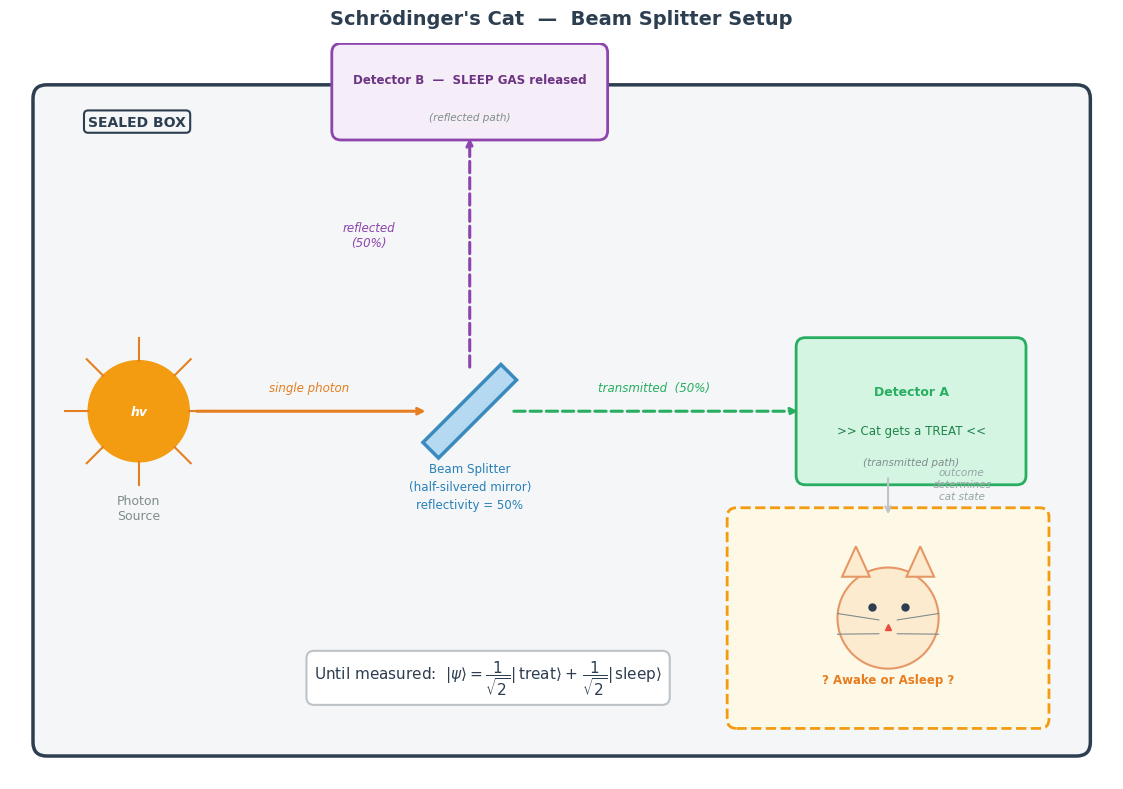

In [2]:
# Run this cell to draw the experimental setup
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from datascience import *
%matplotlib inline

fig, ax = plt.subplots(figsize=(12, 8))
ax.set_xlim(0, 12)
ax.set_ylim(0, 8)
ax.set_aspect('equal')
ax.axis('off')
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

# ── sealed box ──────────────────────────────────────────────────
box = mpatches.FancyBboxPatch((0.4, 0.4), 11.2, 7.0,
    boxstyle='round,pad=0.15', linewidth=2.5,
    edgecolor='#2c3e50', facecolor='#f4f6f7', zorder=0)
ax.add_patch(box)
# Label in top-left corner to avoid overlapping any component
ax.text(0.85, 7.15, 'SEALED BOX', ha='left', va='center',
        fontsize=10, fontweight='bold', color='#2c3e50',
        bbox=dict(facecolor='#f4f6f7', edgecolor='#2c3e50',
                  boxstyle='round,pad=0.3', linewidth=1.5))

# ── photon source (circle with label) ───────────────────────────
src = plt.Circle((1.4, 4.0), 0.55, color='#f39c12', zorder=3)
ax.add_patch(src)
# Star burst rays to suggest a light source
for angle in np.linspace(0, 360, 9)[:-1]:
    rad = np.radians(angle)
    x0, y0 = 1.4 + 0.55*np.cos(rad), 4.0 + 0.55*np.sin(rad)
    x1, y1 = 1.4 + 0.80*np.cos(rad), 4.0 + 0.80*np.sin(rad)
    ax.plot([x0, x1], [y0, y1], color='#e67e22', lw=1.5, zorder=3)
ax.text(1.4, 4.0, 'hv', ha='center', va='center',
        fontsize=9, fontweight='bold', color='white', zorder=4,
        style='italic')
ax.text(1.4, 3.1, 'Photon\nSource', ha='center', va='top',
        fontsize=9, color='#7f8c8d')

# ── incoming photon arrow ────────────────────────────────────────
ax.annotate('', xy=(4.55, 4.0), xytext=(2.0, 4.0),
    arrowprops=dict(arrowstyle='->', color='#e67e22', lw=2.2))
ax.text(3.25, 4.22, 'single photon', ha='center',
        fontsize=8.5, color='#e67e22', style='italic')

# ── beam splitter (diagonal rectangle) ──────────────────────────
bs_cx, bs_cy = 5.0, 4.0
# Draw as a rotated rectangle using a polygon
hw, hh = 0.6, 0.12          # half-width, half-height of the mirror strip
angle = np.radians(45)
corners = np.array([[-hw, -hh], [hw, -hh], [hw, hh], [-hw, hh]])
rot = np.array([[np.cos(angle), -np.sin(angle)],
                [np.sin(angle),  np.cos(angle)]])
rotated = (rot @ corners.T).T + [bs_cx, bs_cy]
mirror = plt.Polygon(rotated, closed=True,
    facecolor='#aed6f1', edgecolor='#2980b9', lw=2.5, zorder=4, alpha=0.9)
ax.add_patch(mirror)
ax.text(bs_cx, bs_cy - 1.05, 'Beam Splitter\n(half-silvered mirror)\nreflectivity = 50%',
        ha='center', fontsize=8.5, color='#2980b9', linespacing=1.5)

# ── transmitted path (→ right to Detector A) ────────────────────
ax.annotate('', xy=(8.6, 4.0), xytext=(5.45, 4.0),
    arrowprops=dict(arrowstyle='->', color='#27ae60', lw=2.2,
                    linestyle='dashed',
                    connectionstyle='arc3,rad=0.0'))
ax.text(7.0, 4.22, 'transmitted  (50%)', ha='center',
        fontsize=8.5, color='#27ae60', style='italic')

# ── reflected path (↑ up to Detector B) ─────────────────────────
ax.annotate('', xy=(5.0, 7.0), xytext=(5.0, 4.45),
    arrowprops=dict(arrowstyle='->', color='#8e44ad', lw=2.2,
                    linestyle='dashed'))
ax.text(3.9, 5.8, 'reflected\n(50%)', ha='center',
        fontsize=8.5, color='#8e44ad', style='italic')

# ── Detector A — Treat (right side, mid-height) ──────────────────
detA = mpatches.FancyBboxPatch((8.65, 3.3), 2.3, 1.4,
    boxstyle='round,pad=0.1', facecolor='#d5f5e3',
    edgecolor='#27ae60', lw=2, zorder=3)
ax.add_patch(detA)
ax.text(9.8, 4.18, 'Detector A', ha='center', fontsize=9,
        fontweight='bold', color='#27ae60')
ax.text(9.8, 3.75, '>> Cat gets a TREAT <<', ha='center',
        fontsize=8.5, color='#1e8449')
ax.text(9.8, 3.42, '(transmitted path)', ha='center',
        fontsize=7.5, color='#7f8c8d', style='italic')

# ── Detector B — Sleep gas (top, centered on reflected path) ─────
detB = mpatches.FancyBboxPatch((3.6, 7.05), 2.8, 0.85,
    boxstyle='round,pad=0.1', facecolor='#f5eef8',
    edgecolor='#8e44ad', lw=2, zorder=3)
ax.add_patch(detB)
ax.text(5.0, 7.57, 'Detector B  —  SLEEP GAS released', ha='center',
        fontsize=8.5, fontweight='bold', color='#6c3483')
ax.text(5.0, 7.17, '(reflected path)', ha='center',
        fontsize=7.5, color='#7f8c8d', style='italic')

# ── cat box (bottom right) ───────────────────────────────────────
cat_box = mpatches.FancyBboxPatch((7.9, 0.65), 3.3, 2.2,
    boxstyle='round,pad=0.1', facecolor='#fef9e7',
    edgecolor='#f39c12', lw=2, linestyle='--', zorder=2)
ax.add_patch(cat_box)
# Simple cat face drawn with matplotlib shapes
cat_cx, cat_cy = 9.55, 1.75
face = plt.Circle((cat_cx, cat_cy), 0.55, facecolor='#fdebd0',
                  edgecolor='#e59866', lw=1.5, zorder=5)
ax.add_patch(face)
# Ears
for dx in [-0.35, 0.35]:
    ear = plt.Polygon([[cat_cx+dx-0.15, cat_cy+0.45],
                        [cat_cx+dx,      cat_cy+0.78],
                        [cat_cx+dx+0.15, cat_cy+0.45]],
                       closed=True, facecolor='#fdebd0',
                       edgecolor='#e59866', lw=1.5, zorder=5)
    ax.add_patch(ear)
# Eyes
for dx in [-0.18, 0.18]:
    ax.plot(cat_cx+dx, cat_cy+0.12, 'o', color='#2c3e50',
            markersize=5, zorder=6)
# Nose
ax.plot(cat_cx, cat_cy-0.1, '^', color='#e74c3c',
        markersize=5, zorder=6)
# Whiskers
for dx, side in [(-1, -1), (1, 1)]:
    for dy in [-0.05, 0.1]:
        ax.plot([cat_cx + side*0.1, cat_cx + side*0.55],
                [cat_cy - 0.12 + dy, cat_cy - 0.1 + dy*1.5],
                color='#7f8c8d', lw=0.8, zorder=6)
ax.text(9.55, 1.04, '? Awake or Asleep ?', ha='center',
        fontsize=8.5, color='#e67e22', fontweight='bold')
# connector line from detectors to cat
ax.annotate('', xy=(9.55, 2.85), xytext=(9.55, 3.3),
    arrowprops=dict(arrowstyle='->', color='#bdc3c7', lw=1.5))
ax.text(10.35, 3.05, 'outcome\ndetermines\ncat state', ha='center',
        fontsize=7.5, color='#95a5a6', style='italic')

# ── superposition equation (bottom center) ───────────────────────
ax.text(5.2, 1.1,
    r'Until measured:  $|\psi\rangle = '
    r'\dfrac{1}{\sqrt{2}}|\,\mathrm{treat}\rangle '
    r'+\, \dfrac{1}{\sqrt{2}}|\,\mathrm{sleep}\rangle$',
    ha='center', va='center', fontsize=11, color='#2c3e50',
    bbox=dict(facecolor='white', edgecolor='#bdc3c7',
              boxstyle='round,pad=0.5', linewidth=1.5))

plt.title("Schrödinger's Cat  —  Beam Splitter Setup",
          fontsize=14, fontweight='bold', color='#2c3e50', pad=14)
plt.tight_layout()
plt.savefig('SCat.png')
plt.show()

---
## Part 1 — One Observation: Opening the Box

When we "open the box" (make a measurement), the photon collapses onto one path with probability `p` for transmitted (treat) and `1-p` for reflected (sleep gas).

For a perfect 50/50 beam splitter, `p = 0.5`.

### ✏️ Exercise 1.1
In the cell below, simulate opening the box **once** by completing the code. Use `np.random.random()` which returns a uniform random number between 0 and 1.

In [ ]:
# Exercise 1.1 — Single measurement
p = 0.5  # probability photon is transmitted → treat

outcome = np.random.random()

# TODO: Write an if/else statement.
# If outcome < p, print "Photon transmitted — Cat gets a treat! 🐟"
# Otherwise, print "Photon reflected  — Cat is asleep! 😴"

# YOUR CODE HERE


### ✏️ Exercise 1.2
Run your cell several times. What do you notice? Is the result always the same?

*Write your answer here (double-click to edit):*

> ...

---
## Part 2 — Many Observations: The Law of Large Numbers

One cat tells us nothing about the probability. But if we run the experiment many times, the *frequency* of each outcome should converge to the true probability.

This is the **Law of Large Numbers** — and it is exactly how quantum mechanics connects to real-world prediction.

### ✏️ Exercise 2.1
Complete the simulation below to run the experiment `n` times and store results in a Table.

In [ ]:
# Exercise 2.1 — Many measurements
p = 0.5
n = 1000  # number of experiments

# TODO: Use np.random.random(n) to generate n random numbers.
# Then create an array of outcomes:
#   'treat'  where random number < p
#   'sleep'  otherwise
# Hint: np.where(condition, value_if_true, value_if_false)

random_numbers = np.random.random(n)
outcomes = ...  # YOUR CODE HERE

# Build a Table with columns 'trial' and 'outcome'
results = Table().with_columns(
    'trial',   np.arange(1, n+1),
    'outcome', outcomes
)
results.show(5)

### ✏️ Exercise 2.2
Use your Table to count how many times each outcome occurred, then compute the *observed frequency* of each. Compare to the theoretical probability `p = 0.5`.

In [ ]:
# Exercise 2.2 — Counting outcomes

# TODO: Use results.group('outcome') to count occurrences of each outcome.
counts = ...  # YOUR CODE HERE
counts.show()

# TODO: Add a column 'frequency' = count / n
# Hint: counts.column('count') gives you the counts array

# YOUR CODE HERE


### ✏️ Exercise 2.3
Now visualize how the **running frequency** of 'treat' changes as you accumulate more trials. This shows the Law of Large Numbers in action.

In [ ]:
# Exercise 2.3 — Running frequency plot

# TODO: Create an array 'running_freq' where element i is the
# fraction of 'treat' outcomes in the first i+1 trials.
# Hint: use np.cumsum() on a boolean array

is_treat = (outcomes == 'treat')           # boolean array
running_freq = ...                          # YOUR CODE HERE

plt.figure(figsize=(9, 4))
plt.plot(np.arange(1, n+1), running_freq, color='#27ae60', lw=1.2, label='Observed frequency')
plt.axhline(p, color='#e74c3c', lw=2, linestyle='--', label=f'True probability p = {p}')
plt.xlabel('Number of trials')
plt.ylabel('Frequency of "treat"')
plt.title('Law of Large Numbers — Beam Splitter Experiment')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

---
## Part 3 — The Wave Function: Probability in Space

The beam splitter gave us two discrete outcomes (treat or sleep). Now we go deeper: Schrödinger's equation governs **continuous** probability — the probability of finding a particle *at a particular position in space*.

### The Particle in a Box

The simplest quantum system is a particle trapped in a 1D box of length `L`. Inside the box, the wave function for energy level `n` is:

$$\psi_n(x) = \sqrt{\frac{2}{L}} \sin\left(\frac{n\pi x}{L}\right)$$

The **probability of finding the particle** near position `x` is:

$$P(x) = |\psi_n(x)|^2$$

This is just a function — and we can plot it, normalize it, and sample from it using the same tools we already have.

### ✏️ Exercise 3.1
Compute and plot `|ψₙ(x)|²` for energy levels n = 1, 2, and 3.

In [ ]:
# Exercise 3.1 — Wave function probability densities
L = 1.0                          # box length (arbitrary units)
x = np.linspace(0, L, 500)       # 500 evenly-spaced positions inside the box

def psi_squared(x, n, L):
    """Returns |ψₙ(x)|² for a particle in a box of length L."""
    # TODO: implement the formula above
    # YOUR CODE HERE
    pass

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
colors = ['#3498db', '#e74c3c', '#2ecc71']

for i, n in enumerate([1, 2, 3]):
    prob = psi_squared(x, n, L)
    axes[i].plot(x, prob, color=colors[i], lw=2)
    axes[i].fill_between(x, prob, alpha=0.25, color=colors[i])
    axes[i].set_title(f'n = {n}', fontsize=13)
    axes[i].set_xlabel('Position x')
    if i == 0:
        axes[i].set_ylabel(r'$|\psi_n(x)|^2$  (probability density)')

fig.suptitle('Particle in a Box — Probability Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### ✏️ Exercise 3.2 — Reflection Questions

Answer the following in the space below (double-click to edit):

1. For n=1, where is the particle *most likely* to be found? Where is it *least likely*?
2. What happens to the number of peaks (antinodes) as n increases? What do you think higher energy means physically?
3. How many locations have zero probability for each n? These are called **nodes**. What is the pattern?

> *1.* ...
>
> *2.* ...
>
> *3.* ...

---
## Part 4 — Simulating a Quantum Measurement

We can simulate many position measurements by **sampling from** `|ψ|²` using it as a set of weights.

`np.random.choice` lets us sample from a discrete set of positions with custom probabilities — exactly like sampling from a loaded die, except the "sides" are positions in space.

### ✏️ Exercise 4.1
Sample 5000 position measurements for n=2 and store results in a Table. Then compare the histogram of measurements to the theoretical `|ψ|²`.

In [ ]:
# Exercise 4.1 — Simulating quantum position measurements
n_level  = 2           # energy level
n_shots  = 5000        # number of "measurements"
n_points = 500         # grid resolution

x = np.linspace(0, L, n_points)
prob = psi_squared(x, n_level, L)

# TODO: Normalize prob so it sums to 1 (required for np.random.choice weights)
weights = ...   # YOUR CODE HERE

# TODO: Use np.random.choice to sample n_shots positions from x using weights
measurements = ...   # YOUR CODE HERE

# Store in a Table
meas_table = Table().with_columns('measured_position', measurements)
meas_table.show(5)

In [ ]:
# Exercise 4.1 continued — Plot histogram vs theoretical distribution
fig, ax = plt.subplots(figsize=(9, 5))

# Histogram of sampled measurements (normalized to density)
ax.hist(measurements, bins=60, density=True, alpha=0.6,
        color='#3498db', label=f'{n_shots} simulated measurements')

# TODO: Overlay the theoretical |ψ|² curve.
# Note: to compare properly, scale prob back to a density.
# Hint: theoretical density = prob * n_points  (undoes the normalization)

# YOUR CODE HERE

ax.set_xlabel('Position x', fontsize=12)
ax.set_ylabel('Probability density', fontsize=12)
ax.set_title(f'Simulated measurements vs $|\psi_{n_level}(x)|^2$', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### ✏️ Exercise 4.2
Change `n_shots` to 100, then 500, then 10000. Describe what happens to the histogram. How does this connect to the Law of Large Numbers from Part 2?

> *Your answer:* ...

---
## Part 5 — Superposition (Challenge)

The real power of quantum mechanics comes from **superposition**: a particle can be in a mixture of energy states simultaneously. The combined wave function is:

$$\psi(x) = \frac{1}{\sqrt{2}}\psi_1(x) + \frac{1}{\sqrt{2}}\psi_2(x)$$

The probabilities of the two states are equal (both have coefficient $\frac{1}{\sqrt{2}}$, and $\left(\frac{1}{\sqrt{2}}\right)^2 = 0.5$).

This is exactly what the equation on the beam splitter diagram described for the cat!

### ✏️ Exercise 5.1
Compute `|ψ_superposition(x)|²` and compare it to the individual states. Then sample from it and plot the results.

In [ ]:
# Exercise 5.1 — Superposition state
x = np.linspace(0, L, 500)

def psi(x, n, L):
    """Returns ψₙ(x) (not squared) for a particle in a box."""
    return np.sqrt(2/L) * np.sin(n * np.pi * x / L)

# TODO: Compute the superposition wave function
# psi_super = (1/sqrt(2)) * psi(x, 1, L) + (1/sqrt(2)) * psi(x, 2, L)
psi_super = ...    # YOUR CODE HERE

# TODO: Compute the probability density |ψ_super|²
prob_super = ...   # YOUR CODE HERE

# Plot all three: n=1, n=2, and the superposition
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

for i, (prob, title, color) in enumerate([
    (psi_squared(x, 1, L), 'n=1 only',        '#3498db'),
    (psi_squared(x, 2, L), 'n=2 only',        '#e74c3c'),
    (prob_super,            'Superposition',   '#8e44ad')
]):
    axes[i].plot(x, prob, color=color, lw=2)
    axes[i].fill_between(x, prob, alpha=0.25, color=color)
    axes[i].set_title(title, fontsize=12)
    axes[i].set_xlabel('Position x')
if True:
    axes[0].set_ylabel(r'$|\psi(x)|^2$')

fig.suptitle('Superposition vs Pure States', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### ✏️ Exercise 5.2 — Big Picture

Reflect on what you've built in this notebook:

1. The beam splitter simulation (Part 1–2) used the same `np.random` tools as a coin flip. What made it *quantum*?
2. The wave function gave us a **continuous** probability distribution over position. How did we turn it into something we could sample from?
3. In real quantum experiments, physicists measure the same particle many times (or many identical particles once). How does the Law of Large Numbers connect their measurements to `|ψ|²`?
4. *(Optional)* Schrödinger was actually *critical* of the probabilistic interpretation. He invented the cat paradox to show it was absurd. Do you think the cat is really in a superposition, or is that just a mathematical convenience? There's no single right answer — physicists still debate this!

> *1.* ...
>
> *2.* ...
>
> *3.* ...
>
> *4.* ...

---
## Summary

| Concept | Classical analogy | Quantum version |
|---|---|---|
| Single outcome | Coin flip | Beam splitter measurement |
| Probability distribution | Loaded die | $\|\psi(x)\|^2$ |
| Many trials → true probability | Law of Large Numbers | Repeated quantum measurements |
| Mixed state | Weighted average of outcomes | Superposition $\psi = c_1\psi_1 + c_2\psi_2$ |

The Schrödinger equation, 100 years old this year, is fundamentally a machine for computing probability distributions. Every simulation technique you used here — sampling, histograms, running frequencies, weighted random choice — is exactly what physicists and quantum computing engineers use to understand and design quantum systems today.